# CodeAlpha Task 4 — Sales Prediction using Python

Predict sales from advertising spend across TV, Radio, and Newspaper channels.

Two regression approaches are compared:
1. `LinearRegression` (scikit-learn baseline)
2. A small feed-forward neural network trained on the GPU (PyTorch + CUDA)

Dataset: `data/Advertising.csv` (Kaggle: bumba5341/advertisingcsv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3060


## 1. Load and explore the data

In [2]:
df = pd.read_csv("data/Advertising.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
print(df.shape)
print(df.isna().sum())
df.describe()

(200, 4)
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


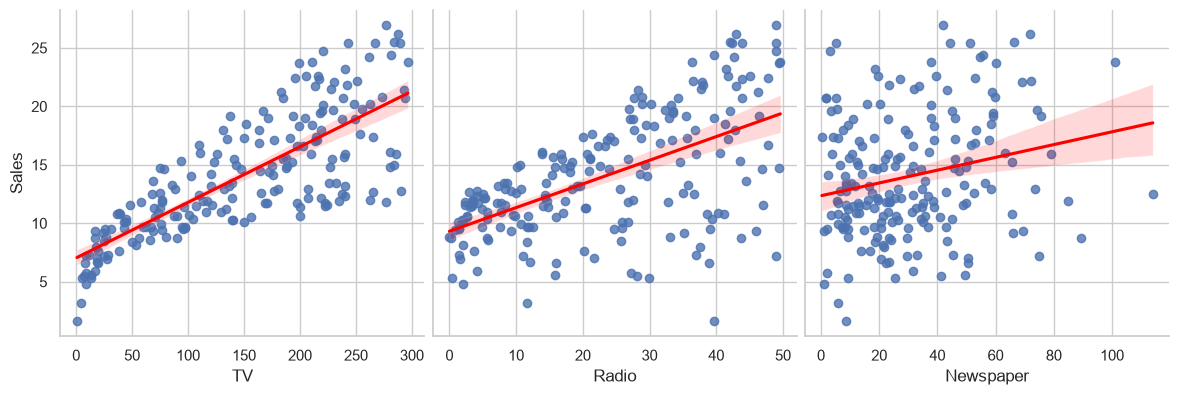

In [4]:
sns.pairplot(df, y_vars=["Sales"], x_vars=["TV", "Radio", "Newspaper"], height=4, kind="reg",
             plot_kws={"line_kws": {"color": "red"}})
plt.show()

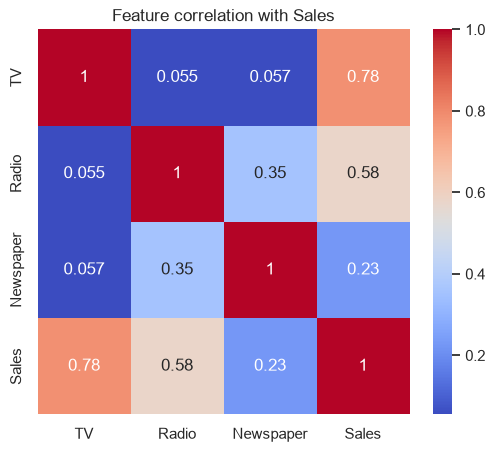

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature correlation with Sales")
plt.show()

Newspaper spend correlates weakly with Sales, while TV and Radio spend are the strongest drivers — this is the actionable insight for marketing budget allocation.

## 2. Preprocess

In [6]:
X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print(X_train_s.shape, X_test_s.shape)

(160, 3) (40, 3)


## 3. Baseline: Linear Regression (scikit-learn, CPU)

LinearRegression -> RMSE: 1.7816 | MAE: 1.4608 | R2: 0.8994


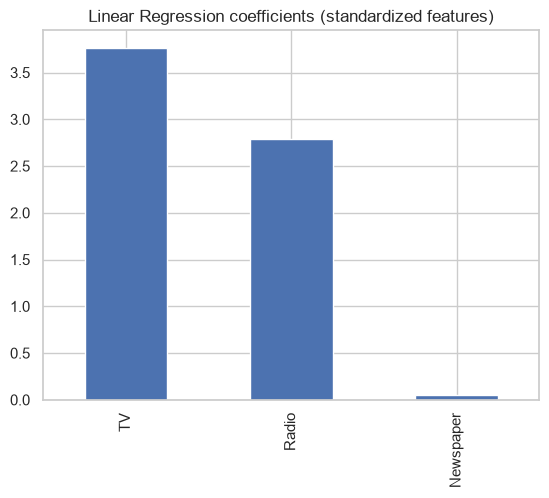

In [7]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"LinearRegression -> RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f} | R2: {lr_r2:.4f}")

coef_df = pd.Series(lr.coef_, index=["TV", "Radio", "Newspaper"])
coef_df.plot(kind="bar", title="Linear Regression coefficients (standardized features)")
plt.show()

## 4. Neural network regressor trained on GPU (PyTorch)

In [8]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32, device=device).view(-1, 1)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_s, dtype=torch.float32, device=device).view(-1, 1)

class SalesNet(nn.Module):
    def __init__(self, in_features=3, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

model = SalesNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)

SalesNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
epochs = 500
history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t)
    history.append((loss.item(), test_loss.item()))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train_loss {loss.item():.5f} | test_loss {test_loss.item():.5f}")

Epoch   50 | train_loss 0.01505 | test_loss 0.01777


Epoch  100 | train_loss 0.00857 | test_loss 0.01377
Epoch  150 | train_loss 0.00599 | test_loss 0.01342
Epoch  200 | train_loss 0.00427 | test_loss 0.01437


Epoch  250 | train_loss 0.00304 | test_loss 0.01616
Epoch  300 | train_loss 0.00208 | test_loss 0.01620
Epoch  350 | train_loss 0.00167 | test_loss 0.01776
Epoch  400 | train_loss 0.00148 | test_loss 0.01801


Epoch  450 | train_loss 0.00133 | test_loss 0.01771
Epoch  500 | train_loss 0.00120 | test_loss 0.01789


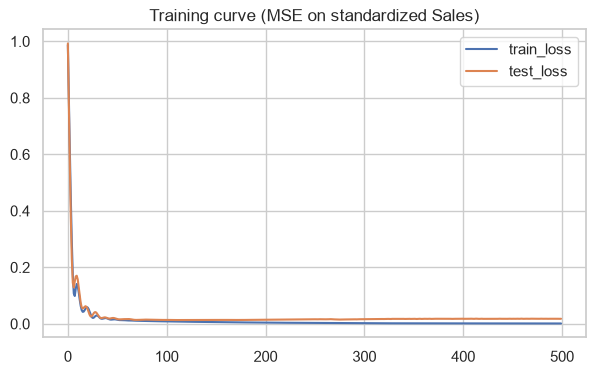

In [10]:
hist_df = pd.DataFrame(history, columns=["train_loss", "test_loss"])
hist_df.plot(figsize=(7, 4), title="Training curve (MSE on standardized Sales)")
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    nn_pred_s = model(X_test_t).cpu().numpy()
nn_pred = y_scaler.inverse_transform(nn_pred_s).ravel()

nn_rmse = mean_squared_error(y_test, nn_pred) ** 0.5
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)
print(f"PyTorch NN -> RMSE: {nn_rmse:.4f} | MAE: {nn_mae:.4f} | R2: {nn_r2:.4f}")

PyTorch NN -> RMSE: 0.6812 | MAE: 0.4466 | R2: 0.9853


## 5. Predicted vs actual & final comparison

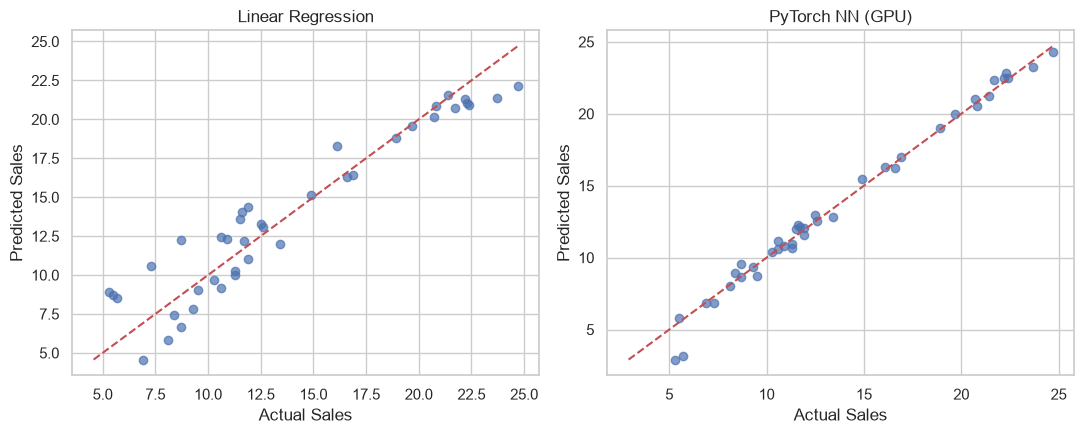

Model                   RMSE     MAE      R2
Linear Regression      1.782   1.461   0.899
PyTorch NN (GPU)       0.681   0.447   0.985


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(axes, [lr_pred, nn_pred], ["Linear Regression", "PyTorch NN (GPU)"]):
    ax.scatter(y_test, pred, alpha=0.7)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(f"{'Model':<20}{'RMSE':>8}{'MAE':>8}{'R2':>8}")
print(f"{'Linear Regression':<20}{lr_rmse:>8.3f}{lr_mae:>8.3f}{lr_r2:>8.3f}")
print(f"{'PyTorch NN (GPU)':<20}{nn_rmse:>8.3f}{nn_mae:>8.3f}{nn_r2:>8.3f}")

## 6. Business insight

TV and Radio advertising spend are the dominant drivers of Sales; Newspaper spend has little predictive value and could be reduced in favor of TV/Radio budget without materially hurting sales.